# **Implementing Naive Bayes**

In [22]:
#importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn .metrics import accuracy_score,precision_score,confusion_matrix


In [3]:
# Importing data
df=pd.read_csv('tennisdata.csv')

In [4]:
df.head()

,Outlook,Temperature,Humidity,Windy,PlayTennis
0,Sunny,Hot,High,False,No
1,Sunny,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Rainy,Mild,High,False,Yes
4,Rainy,Cool,Normal,False,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Windy        14 non-null     bool  
 4   PlayTennis   14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [6]:
df.isnull().sum()

,0
Outlook,0
Temperature,0
Humidity,0
Windy,0
PlayTennis,0


In [9]:
X=df.iloc[:,:4]

In [10]:
X

,Outlook,Temperature,Humidity,Windy
0,Sunny,Hot,High,False
1,Sunny,Hot,High,True
2,Overcast,Hot,High,False
3,Rainy,Mild,High,False
4,Rainy,Cool,Normal,False
5,Rainy,Cool,Normal,True
6,Overcast,Cool,Normal,True
7,Sunny,Mild,High,False
8,Sunny,Cool,Normal,False
9,Rainy,Mild,Normal,False


In [11]:
Y=df.iloc[:,-1]

In [12]:
Y

,PlayTennis
0,No
1,No
2,Yes
3,Yes
4,Yes
5,No
6,Yes
7,No
8,Yes
9,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      14 non-null     object
 1   Temperature  14 non-null     object
 2   Humidity     14 non-null     object
 3   Windy        14 non-null     bool  
 4   PlayTennis   14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [15]:
le=LabelEncoder()
X['Outlook']=le.fit_transform(X['Outlook'])
X['Temperature']=le.fit_transform(X['Temperature'])
X['Humidity']=le.fit_transform(X['Humidity'])
X['Windy']=le.fit_transform(X['Windy'])
Y=le.fit_transform(Y)

In [16]:
# Train Test Split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:
# Model training:
model=GaussianNB()
model.fit(X_train,Y_train)

GaussianNB()

In [20]:
# Model Predict
Y_pred=model.predict(X_test)

In [21]:
# Performance evaluation:
print(f"Accuracy:{accuracy_score(Y_test,Y_pred):.2f}")

Accuracy:1.00


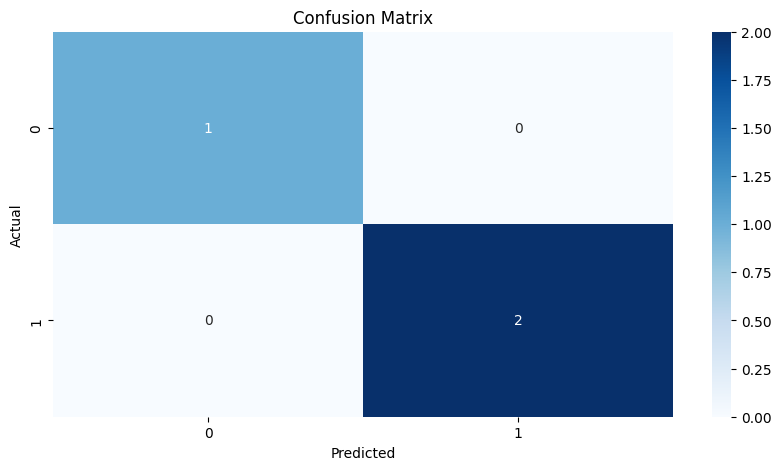

In [25]:
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(Y_test,Y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()